## Grievance Data Cleaning and Initial Analysis

1. Data Source: 
Grievance records extracted from the Odisha Janasunani grievance management system, supplemented with official administrative reference datasets.

2. Objective:
The goal of this notebook is to perform initial data quality checks and identify structural issues before standardised cleaning.

3. Scope of Checks
- Completeness and missing value profiling
- Categorical consistency audits
- ID–name validation against admin reference hierarchies
- Cross-tab analysis to identify systematic inconsistencies
- Category-specific deep-dives for high-volume complaint domains

4. Key Observations
- Certain fields are fully populated but semantically inconsistent
- Category–subcategory mismatches indicate admin mapping issues

5. Next Steps
- Convert this notebook into a reproducible script
- Generate a clean, analysis-ready dataset



## 1. Environment Setup and Imports
This section sets up the Python environment and confirms the working directory.

In [1]:
import os
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [2]:
def set_working_directory(path):
    os.chdir(path)
    print("Current working directory:", os.getcwd())

In [3]:
def load_complaints(db_path):
    conn = sqlite3.connect(db_path)
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table';", conn
    )
    df = pd.read_sql_query("SELECT * FROM complaints;", conn)
    conn.close()
    return df, tables


## 2. Data Source and Loading
The grievance data is stored in a SQLite database.
All records are loaded from the complaints table

In [4]:
set_working_directory("/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Trial")

db_path = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/grievance_complaints.db"

df, tables = load_complaints(db_path)
tables

Current working directory: /Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Trial


,name
0,complaints


## 3. Creating a Working Copy
A working copy (df_work) is created to ensure the raw dataset remains untouched.

In [5]:
def create_working_copy(df):
    df_work = df.copy()
    print("Raw shape:", df.shape)
    print("Working copy shape:", df_work.shape)
    return df_work

In [6]:
df_work = create_working_copy(df)

Raw shape: (1371288, 50)
Working copy shape: (1371288, 50)


In [7]:
df_work.info()
df_work.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371288 entries, 0 to 1371287
Data columns (total 50 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id                       1371288 non-null  int64  
 1   ticket_no                1371288 non-null  object 
 2   petitioner_name          1371174 non-null  object 
 3   petitioner_mobile        1370545 non-null  object 
 4   petitioner_email         1356047 non-null  object 
 5   grievance                1371285 non-null  object 
 6   document_url             1047100 non-null  object 
 7   office_id                1371288 non-null  int64  
 8   office                   1311838 non-null  object 
 9   received_by              1371278 non-null  object 
 10  district_id              1366678 non-null  float64
 11  district                 1361869 non-null  object 
 12  block_id                 1371288 non-null  int64  
 13  block                    1134155 non-null 

,id,ticket_no,petitioner_name,petitioner_mobile,petitioner_email,grievance,document_url,office_id,office,received_by,...,local_document_path,document_downloaded,document_download_date,document_download_error,trackingId,review_authority,review_authority_name,vch_all_esc_user,reopened_by,vch_account
0,1,C132910,Subhabr49917722,******rata,,&lt;a href=&quot;http://www.twitter.com/CMCCut...,None,0,None,Chief Minister Office,...,None,0,None,None,1377613503155036161,81,Chief Minister Office,"73,44,81",None,MENTION_TW
1,2,C143339,JasobantaRana2,******nta,,Respected &lt;a href=&quot;http://www.twitter....,None,0,None,Chief Minister Office,...,None,0,None,None,1388252153962065922,81,Chief Minister Office,"2,54,81",None,MENTION_TW
2,3,C149351,Bishwaksenkuanr,******ksen,,&lt;a href=&quot;http://www.twitter.com/CMO_Od...,None,0,None,Chief Minister Office,...,None,0,None,None,1393753306774728706,81,Chief Minister Office,"7,54,81",None,MENTION_TW
3,4,C150702,frozenfire_aj,******Kuma,,&lt;a href=&quot;http://www.twitter.com/SonuSo...,None,0,None,Chief Minister Office,...,None,0,None,None,1394890123616030721,81,Chief Minister Office,"12,43,81",None,MENTION_TW
4,5,C165110,woymforpeople,******n Od,,"Gita Naik, A widow alongwith 3 daughter living...",None,0,None,Chief Minister Office,...,None,0,None,None,1407958304760819713,81,Chief Minister Office,"16,62,81",None,MENTION_TW


In [8]:
df_work.columns

Index(['id', 'ticket_no', 'petitioner_name', 'petitioner_mobile',
       'petitioner_email', 'grievance', 'document_url', 'office_id', 'office',
       'received_by', 'district_id', 'district', 'block_id', 'block',
       'address', 'mode', 'disability', 'status', 'govt_ticket', 'created_on',
       'tagged_to', 'tagged_by', 'tagged_date', 'category_id', 'category',
       'dept_id', 'dept', 'subcategory_id', 'subcategory', 'state',
       'petitioner_gender', 'transfer_status', 'urgent', 'pending_with',
       'assigned_on', 'escalation_date', 'self_assign', 'resolved_by',
       'resolved_on', 'benefitted', 'local_document_path',
       'document_downloaded', 'document_download_date',
       'document_download_error', 'trackingId', 'review_authority',
       'review_authority_name', 'vch_all_esc_user', 'reopened_by',
       'vch_account'],
      dtype='object')

## 4. Column Selection for Analysis

Only analytically relevant columns are retained to ensure consistency.

In [9]:
def select_analysis_columns(df_work):
    analysis_cols = [
        'id','ticket_no','grievance','document_url',
        'office_id','office','received_by',
        'district_id','district','mode','disability','status','created_on',
        'category_id','category','dept_id','dept',
        'subcategory_id','subcategory','state','petitioner_gender'
    ]
    return df_work[analysis_cols].copy()

In [10]:
df_work = select_analysis_columns(df_work)
df_work.shape

(1371288, 21)

In [11]:
df_work.info()
df_work.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371288 entries, 0 to 1371287
Data columns (total 21 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   id                 1371288 non-null  int64  
 1   ticket_no          1371288 non-null  object 
 2   grievance          1371285 non-null  object 
 3   document_url       1047100 non-null  object 
 4   office_id          1371288 non-null  int64  
 5   office             1311838 non-null  object 
 6   received_by        1371278 non-null  object 
 7   district_id        1366678 non-null  float64
 8   district           1361869 non-null  object 
 9   mode               1371288 non-null  object 
 10  disability         818829 non-null   object 
 11  status             1371288 non-null  object 
 12  created_on         1371288 non-null  object 
 13  category_id        1371288 non-null  int64  
 14  category           1139836 non-null  object 
 15  dept_id            1371288 non-n

Index(['id', 'ticket_no', 'grievance', 'document_url', 'office_id', 'office',
       'received_by', 'district_id', 'district', 'mode', 'disability',
       'status', 'created_on', 'category_id', 'category', 'dept_id', 'dept',
       'subcategory_id', 'subcategory', 'state', 'petitioner_gender'],
      dtype='object')

Missing value for selected columns

In [12]:
def missing_value_summary(df):
    missing_pct = (
        df.isnull().mean()
        .mul(100)
        .round(2)
    )

    return (
        missing_pct
        .reset_index()
        .rename(columns={'index':'column', 0:'missing_pct'})
        .sort_values('missing_pct', ascending=False)
    )

missing_summary = missing_value_summary(df_work)
display(missing_summary)

,column,missing_pct
10,disability,40.29
3,document_url,23.64
14,category,16.88
16,dept,15.35
18,subcategory,15.09
5,office,4.34
8,district,0.69
7,district_id,0.34
19,state,0.01
13,category_id,0.00


## 5. AUDITS

Generic Audit Helpers

In [13]:
def value_counts_full(df, col):
    """
     Returns value counts including NaN.
    """
    return df[col].value_counts(dropna=False) 

def non_null_counts(df, cols):
    """
    Returns non-null counts for multiple columns.
    """
    return {col: df[col].notna().sum() for col in cols}

def null_counts(df, cols):
    """
    Returns null counts for multiple columns.
    """
    return {col: df[col].isna().sum() for col in cols}


def unique_values(df, col):
    """
    Returns unique values in a column (including NaN).
    """
    return df[col].unique()

def unique_combinations(df, id_col, name_col):
    """
    Returns a DataFrame with counts of unique (id, name) combinations,
    including NaN values.
    """
    return (
        df[[id_col, name_col]]
        .value_counts(dropna=False)
        .reset_index(name="count")
    )
 

def type_audit(df, col):
    """
    Returns counts of Python data types present in a column.
    """
    return df[col].apply(type).value_counts()


def categorical_audit(df, col):
    """
    Returns a DataFrame with value, count, and percentage (including NaN).
    """
    vc = value_counts_full(df, col)

    return pd.DataFrame({
        "value": vc.index,
        "count": vc.values,
        "percentage": (vc.values / len(df) * 100).round(2)
    })


def _crosstab(df, row, col, normalize=False):
    return pd.crosstab(
        df[row],
        df[col],
        dropna=False,
        normalize='index' if normalize else False
    )


def crosstab_counts(df, row, col):
    """
    Crosstab counts between two columns.
    """
    return _crosstab(df, row, col)


def crosstab_percent(df, row, col):
    """
    Row-normalised crosstab percentages.
    """
    return (_crosstab(df, row, col, normalize=True) * 100).round(2)



def head_rows(df, cols, n=5):
    """
    Returns first n rows of the dataframe.
    Optionally limits to specific columns.
    """
    return df[cols].head(n)


GENERIC ID–NAME VALIDATION FUNCTION

In [14]:
def validate_id_name_mapping(
    df,
    id_col,
    name_col,
    ref_df,
    ref_id_col,
    ref_name_col
):
    """
    Generic ID–Name consistency check.
    Works for district, dept, office, category, subcategory.
    """

    # Prepare complaint-side data
    df_check = df[[id_col, name_col]].drop_duplicates().copy()
    df_check[name_col] = (
        df_check[name_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Prepare reference data
    ref_df = ref_df.copy()
    ref_df[ref_name_col] = (
        ref_df[ref_name_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    # Merge
    merged = df_check.merge(
        ref_df[[ref_id_col, ref_name_col]],
        left_on=id_col,
        right_on=ref_id_col,
        how="left",
        indicator=True
    )

    merged["match_status"] = merged["_merge"].map({
        "both": "Matched",
        "left_only": "Not Matched"
    })

    summary = merged["match_status"].value_counts()

    unmatched = merged[
        merged["match_status"] == "Not Matched"
    ][[id_col, name_col]]

    return {
        "validation_table": merged.drop(columns="_merge"),
        "summary": summary,
        "unmatched": unmatched
    }


### 5.1. Disability
The disability column is examined to:
- Show full value counts (including NaN) and the underlying data types.
- Verify whether values are stored consistently (e.g., strings vs. None vs. actual NaN values)

A cross-tabulation (pd.crosstab) is used to examine:
- Counts and percentages of disability values across mode (e.g., Website, WhatsApp, Physical, Letter, CMO visits).

This helps answer questions like:
- Are disability fields more frequently left blank in particular modes?
- Is there a pattern suggesting UI or process issues for certain channels

In [15]:
categorical_audit(df_work, 'disability')

,value,count,percentage
0,None,769149,56.09
1,None,552459,40.29
2,Other Disability,29210,2.13
3,Locomotor Disability /Cerebral Palsy,12301,0.90
4,Blindness / Low Vision,4858,0.35
5,Mental Illness,3311,0.24


In [16]:
type_audit(df_work, 'disability')

disability
<class 'str'>         818829
<class 'NoneType'>    552459
Name: count, dtype: int64

In [17]:
non_null_counts(df_work, ['disability'])

{'disability': np.int64(818829)}

In [18]:
crosstab_counts(df_work, 'disability', 'mode')

mode,CM Weekly Grievance,CMO District Visit I - Community Grievance,CMO District Visit I - Individual Grievance,CMO District Visit II - Community Grievance,CMO District Visit II - Individual Grievance,Email,Facebook,Joint Hearing,Letter,Mobile,Physical,Twitter,Urgent,Website,Whatsapp
disability,,,,,,,,,,,,,,,
Blindness / Low Vision,25,2,4,3,11,8,0,94,62,174,385,0,0,3456,634
Locomotor Disability /Cerebral Palsy,96,5,17,31,49,43,0,529,341,1174,1109,0,0,7544,1363
Mental Illness,8,0,4,5,7,7,0,67,33,351,130,0,0,2215,484
None,11702,7610,1478,27381,6696,8574,0,49893,39612,19293,88504,0,333,470318,37755
Other Disability,145,31,26,261,145,22,0,635,423,2649,1093,0,3,17178,6599
NaN,43,36579,10647,152,91,26826,47,422,25451,20069,68781,59465,2,243475,60409


In [19]:
crosstab_percent(df, 'disability', 'mode')

mode,CM Weekly Grievance,CMO District Visit I - Community Grievance,CMO District Visit I - Individual Grievance,CMO District Visit II - Community Grievance,CMO District Visit II - Individual Grievance,Email,Facebook,Joint Hearing,Letter,Mobile,Physical,Twitter,Urgent,Website,Whatsapp
disability,,,,,,,,,,,,,,,
Blindness / Low Vision,0.51,0.04,0.08,0.06,0.23,0.16,0.00,1.93,1.28,3.58,7.93,0.00,0.00,71.14,13.05
Locomotor Disability /Cerebral Palsy,0.78,0.04,0.14,0.25,0.40,0.35,0.00,4.30,2.77,9.54,9.02,0.00,0.00,61.33,11.08
Mental Illness,0.24,0.00,0.12,0.15,0.21,0.21,0.00,2.02,1.00,10.60,3.93,0.00,0.00,66.90,14.62
None,1.52,0.99,0.19,3.56,0.87,1.11,0.00,6.49,5.15,2.51,11.51,0.00,0.04,61.15,4.91
Other Disability,0.50,0.11,0.09,0.89,0.50,0.08,0.00,2.17,1.45,9.07,3.74,0.00,0.01,58.81,22.59
NaN,0.01,6.62,1.93,0.03,0.02,4.86,0.01,0.08,4.61,3.63,12.45,10.76,0.00,44.07,10.93


### 5.2. Petitioner Gender

In [20]:
categorical_audit(df_work, 'petitioner_gender')

,value,count,percentage
0,Male,610008,44.48
1,Female,463562,33.80
2,Other,296903,21.65
3,Transgender,815,0.06


### 5.3. Ticket Number 
The ticket_no field is audited for:
- Duplicate values across the dataset.
- Number of unique ticket numbers vs. total rows.
- Ticket length distribution:

It then links ticket length to complaint creation time by:
- Converting created_on to datetime.
- Grouping by ticket_length and summarising the earliest and latest dates for each length.

This reveals:
- Historical changes in ticket formats.
- Periods where a specific ticket format dominates, suggesting system upgrades or schema revisions.

In [21]:
categorical_audit(df_work, 'ticket_no')

,value,count,percentage
0,C132910,1,0.0
1,DM2023234693,1,0.0
2,DEPT2023230552,1,0.0
3,DEPT2023231265,1,0.0
4,CMO2023230162,1,0.0
...,...,...,...
1371283,SP202293213,1,0.0
1371284,GOV202294692,1,0.0
1371285,CMO202296914,1,0.0
1371286,DM202294696,1,0.0


In [22]:
type_audit(df_work, 'ticket_no')

ticket_no
<class 'str'>    1371288
Name: count, dtype: int64

In [23]:
null_counts(df_work, ['ticket_no'])

{'ticket_no': np.int64(0)}

In [24]:
non_null_counts(df_work, ['ticket_no'])

{'ticket_no': np.int64(1371288)}

In [25]:
def ticket_length_distribution(df):
    return df['ticket_no'].astype(str).str.len().value_counts().sort_index()

def ticket_length_examples(df, n=5):
    for length in sorted(df['ticket_no'].astype(str).str.len().unique()):
        print(f"\nTicket length = {length}")
        print(
            df.loc[
                df['ticket_no'].astype(str).str.len()==length,
                'ticket_no'
            ].head(n).to_list()
        )

def ticket_length_date_range(df):
    df = df.copy()
    df['created_on'] = pd.to_datetime(df['created_on'], errors='coerce')
    df['ticket_length'] = df['ticket_no'].astype(str).str.len()
    return (
        df.groupby('ticket_length')['created_on']
          .agg(['min','max'])
          .sort_index()
    )


In [26]:
ticket_length_distribution(df_work)

ticket_no
7      58939
11     57931
12    599037
13    307192
14    252734
15     67433
17       338
18     27684
Name: count, dtype: int64

In [27]:
ticket_length_examples(df_work)



Ticket length = 7
['C132910', 'C143339', 'C149351', 'C150702', 'C165110']

Ticket length = 11
['DM202108451', 'SP202112653', 'DM202114686', 'SP202219079', 'DM202220158']

Ticket length = 12
['CMO202100019', 'CMO202102387', 'CMO202103782', 'CMO202218570', 'CMO202225613']

Ticket length = 13
['DEPT202101180', 'DEPT202226527', 'DEPT202234869', 'DEPT202236643', 'DEPT202237768']

Ticket length = 14
['DEPT2022104524', 'DEPT2022108498', 'DEPT2022118481', 'DEPT2022120916', 'DEPT2022130173']

Ticket length = 15
['DEPT20241010126', 'DEPT20241026968', 'DEPT20241025428', 'DEPT20241023573', 'DEPT20241044383']

Ticket length = 17
['URGENT20251232180', 'URGENT20251235997', 'URGENT20251248139', 'URGENT20251235751', 'URGENT20251239031']

Ticket length = 18
['CMOFF/E/2021/10899', 'OR149/E/2021/00593', 'CMOFF/E/2021/18868', 'OR180/D/2021/01178', 'OR171/P/2021/00429']


In [28]:
ticket_length_date_range(df_work)

,min,max
ticket_length,,
7,2021-04-01 10:17:02,2025-07-29 17:58:22
11,2021-10-30 21:34:49,2022-09-25 17:59:58
12,2021-10-30 22:25:28,2024-11-29 11:17:54
13,2021-11-01 07:57:33,2025-07-30 11:34:52
14,2022-09-25 18:04:53,2025-07-30 11:31:39
15,2024-11-29 11:20:59,2025-07-30 11:34:18
17,2025-05-27 13:23:25,2025-07-10 16:39:39
18,2021-04-05 00:00:00,2021-10-31 00:00:00


### 5.4. ID Column 

In [29]:
value_counts_full(df_work, 'id')

id
1          1
914199     1
914197     1
914196     1
914195     1
          ..
457096     1
457095     1
457094     1
457093     1
1371288    1
Name: count, Length: 1371288, dtype: int64

In [30]:
unique_values(df_work, 'id')

array([      1,       2,       3, ..., 1371286, 1371287, 1371288])

In [31]:
head_rows(df_work, cols=['id'], n=10)

,id
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


### 5.5. Document URL
- Transform `document_url` into a simple `document_attached` yes/no flag, and then examine how attachments vary across modes. 

- Mode vs Document Attachment Crosstab
To compare each complaint submission mode with whether a supporting document was attached. It helps identify which modes (online or offline) tend to include attachments more often.


In [32]:
value_counts_full(df_work, 'document_url')

document_url
None                                                                                                                          324188
https://janasunani.odisha.gov.in/getfileApi/uploads/ecomplaint/2022EA/CRM_null__COGNIZANCE~pdf                                    40
https://janasunani.odisha.gov.in/getfileApi/uploads/ecomplaint/2022EA/CRM_null__83414~pdf                                         11
https://janasunani.odisha.gov.in/getfileApi/uploads/ecomplaint/2022EA/CRM_null__DOC-20220916-WA0024~~pdf                           7
https://janasunani.odisha.gov.in/getfileApi/uploads/ecomplaint/2022EA/CRM_null__chitra ranjan~pdf                                  7
                                                                                                                               ...  
https://janasunani.odisha.gov.in/getfileApi/uploads/ecomplaint/2025EA/abhijogaDoc20250129_0537161738129036784_9823~pdf             1
https://janasunani.odisha.gov.in/getfileApi/uploads/ecom

In [33]:
categorical_audit(df_work, 'document_url')

,value,count,percentage
0,None,324188,23.64
1,https://janasunani.odisha.gov.in/getfileApi/up...,40,0.00
2,https://janasunani.odisha.gov.in/getfileApi/up...,11,0.00
3,https://janasunani.odisha.gov.in/getfileApi/up...,7,0.00
4,https://janasunani.odisha.gov.in/getfileApi/up...,7,0.00
...,...,...,...
1046836,https://janasunani.odisha.gov.in/getfileApi/up...,1,0.00
1046837,https://janasunani.odisha.gov.in/getfileApi/up...,1,0.00
1046838,https://janasunani.odisha.gov.in/getfileApi/up...,1,0.00
1046839,https://janasunani.odisha.gov.in/getfileApi/up...,1,0.00


In [34]:
null_counts(df_work, ['document_url'])

{'document_url': np.int64(324188)}

In [35]:
non_null_counts(df_work, ['document_url'])

{'document_url': np.int64(1047100)}

In [36]:
# Create binary variable Yes/No for document attached
def add_document_flag(df):
    df = df.copy()
    df['document_attached'] = np.where(
        df['document_url'].notna(),'Yes','No'
    )
    return df

# Create crosstab between mode and document attached
def mode_vs_document(df):
    return pd.crosstab(
        df['mode'],
        df['document_attached'],
        normalize='index',
        margins=True
    )

In [37]:
df_work = add_document_flag(df_work)

In [38]:
categorical_audit(df_work, 'document_attached')

,value,count,percentage
0,Yes,1047100,76.36
1,No,324188,23.64


In [39]:
head_rows(df_work, cols=['document_url', 'document_attached'], n=10)

,document_url,document_attached
0,None,No
1,None,No
2,None,No
3,None,No
4,None,No
5,None,No
6,None,No
7,https://janasunani.odisha.gov.in/getfileApi/up...,Yes
8,https://janasunani.odisha.gov.in/getfileApi/up...,Yes
9,https://janasunani.odisha.gov.in/getfileApi/up...,Yes


In [40]:
mode_vs_document(df_work)

document_attached,No,Yes
mode,,
CM Weekly Grievance,0.004493,0.995507
CMO District Visit I - Community Grievance,0.145341,0.854659
CMO District Visit I - Individual Grievance,0.173456,0.826544
CMO District Visit II - Community Grievance,0.002910,0.997090
CMO District Visit II - Individual Grievance,0.002143,0.997857
Email,0.187486,0.812514
Facebook,1.000000,0.000000
Joint Hearing,0.003776,0.996224
Letter,0.011028,0.988972


### 5.6. Mode
Check the `mode` field for basic distribution and missingness, which helps understand channel usage and workflow states.

In [41]:
categorical_audit(df_work, 'mode')

,value,count,percentage
0,Website,744186,54.27
1,Physical,160002,11.67
2,Whatsapp,107244,7.82
3,Letter,65922,4.81
4,Twitter,59465,4.34
5,Joint Hearing,51640,3.77
6,CMO District Visit I - Community Grievance,44227,3.23
7,Mobile,43710,3.19
8,Email,35480,2.59
9,CMO District Visit II - Community Grievance,27833,2.03


In [42]:
null_counts(df_work, ['mode'])

{'mode': np.int64(0)}

In [43]:
non_null_counts(df_work, ['mode'])

{'mode': np.int64(1371288)}

In [44]:
online_modes = [
    'Website', 'Whatsapp', 'Twitter', 'Email', 'Mobile', 'Facebook'
]

online_count = df_work['mode'].isin(online_modes).sum()
offline_count = len(df_work) - online_count

online_pct = round(online_count / len(df_work) * 100, 2)
offline_pct = round(offline_count / len(df_work) * 100, 2)
online_pct, offline_pct


(np.float64(72.2), np.float64(27.8))

### 5.7. Status

In [45]:
categorical_audit(df_work, 'status')

,value,count,percentage
0,Disposed,1017795,74.22
1,Discard,191264,13.95
2,Open,52130,3.80
3,Replied,42095,3.07
4,Forwarded To Subordinate,31731,2.31
5,Not Assigned,26378,1.92
6,Reopen,4113,0.30
7,Forward,3675,0.27
8,RESOLVED_POSTING,1750,0.13
9,Accepted,239,0.02


In [46]:
null_counts(df_work, ['status'])

{'status': np.int64(0)}

In [47]:
non_null_counts(df_work, ['status'])

{'status': np.int64(1371288)}

### 5.8. Created_On 
Derive multiple time components (year, month, day, weekday, hour) from `created_on` for later trend analysis.

In [48]:
head_rows(df_work, cols=['created_on'], n=10)

,created_on
0,2021-04-01 19:09:34.000000
1,2021-05-01 10:39:47.000000
2,2021-05-16 12:11:30.000000
3,2021-05-19 14:30:32.000000
4,2021-06-24 13:59:04.000000
5,2021-07-23 20:10:39.000000
6,2021-09-09 11:20:57.000000
7,2021-11-01 09:35:18.000000
8,2021-11-09 09:00:34.000000
9,2021-11-15 13:35:06.000000


In [49]:
null_counts(df_work, ['created_on'])

{'created_on': np.int64(0)}

In [50]:
#Range of Created_On dates
df_work['created_on'].agg(['min', 'max'])


min    2021-04-01 10:17:02.000000
max    2025-07-30 11:34:52.000000
Name: created_on, dtype: object

In [51]:
#Add time-based columns
def enrich_created_on(df):
    df = df.copy()
    df['created_on'] = pd.to_datetime(df['created_on'], errors='coerce')

    df['year'] = df['created_on'].dt.year
    df['month'] = df['created_on'].dt.month
    df['month_name'] = df['created_on'].dt.month_name()
    df['day'] = df['created_on'].dt.day
    df['day_of_week'] = df['created_on'].dt.day_name()
    df['hour'] = df['created_on'].dt.hour
    df['date'] = df['created_on'].dt.date

    return df
df_work = enrich_created_on(df_work)

In [52]:
df_work[['created_on', 'year', 'month_name', 'day', 'day_of_week', 'hour', 'date']].head(10)

,created_on,year,month_name,day,day_of_week,hour,date
0,2021-04-01 19:09:34,2021,April,1,Thursday,19,2021-04-01
1,2021-05-01 10:39:47,2021,May,1,Saturday,10,2021-05-01
2,2021-05-16 12:11:30,2021,May,16,Sunday,12,2021-05-16
3,2021-05-19 14:30:32,2021,May,19,Wednesday,14,2021-05-19
4,2021-06-24 13:59:04,2021,June,24,Thursday,13,2021-06-24
5,2021-07-23 20:10:39,2021,July,23,Friday,20,2021-07-23
6,2021-09-09 11:20:57,2021,September,9,Thursday,11,2021-09-09
7,2021-11-01 09:35:18,2021,November,1,Monday,9,2021-11-01
8,2021-11-09 09:00:34,2021,November,9,Tuesday,9,2021-11-09
9,2021-11-15 13:35:06,2021,November,15,Monday,13,2021-11-15


### 5.9. State 
check how `state` is recorded, including types, missingness, and examples of rows where state is missing

In [53]:
categorical_audit(df_work, 'state')

,value,count,percentage
0,ODISHA,1366623,99.66
1,DELHI,1032,0.08
2,MADHYA PRADESH,881,0.06
3,WEST BENGAL,464,0.03
4,BIHAR,438,0.03
5,None,200,0.01
6,UTTAR PRADESH,196,0.01
7,ANDHRA PRADESH,161,0.01
8,MAHARASHTRA,158,0.01
9,JHARKHAND,147,0.01


In [54]:
type_audit(df_work, 'state')

state
<class 'str'>         1371088
<class 'NoneType'>        200
Name: count, dtype: int64

In [55]:
null_counts(df_work, ['state'])

{'state': np.int64(200)}

In [56]:
non_null_counts(df_work, ['state'])

{'state': np.int64(1371088)}

### 5.10. District & District ID Checks
To inspect the joint behaviour of `district` and `district_id` to find:

- Missingness on either column.
- Unique district–ID combinations.
- Suspicious mappings that suggest data issues.

From this, preliminary insights are documented:
- Records from non-Odisha states often have district_id = 0 or NaN.
- Several Odisha districts appear linked to multiple states.
- Some combinations are clearly impossible (e.g., Odisha districts under states like Haryana or Delhi).

In [57]:
head_rows(df_work, ['district_id', 'district'])


,district_id,district
0,350.0,Cuttack
1,344.0,Angul
2,349.0,Boudh
3,362.0,Khordha
4,NaN,None


In [58]:
null_counts(df_work, ['district_id', 'district'])

{'district_id': np.int64(4610), 'district': np.int64(9419)}

In [59]:
non_null_counts(df_work, ['district_id', 'district'])

{'district_id': np.int64(1366678), 'district': np.int64(1361869)}

In [60]:
unique_values(df_work, 'district')

array(['Cuttack', 'Angul', 'Boudh', 'Khordha', None, 'Dhenkanal',
       'Ganjam', 'Kendujhar', 'Jagatsinghapur', 'Baleswar', 'Jajpur',
       'Bhadrak', 'Kendrapara', 'Gajapati', 'Jharsuguda', 'Kandhamal',
       'Kalahandi', 'Koraput', 'Balangir', 'Puri', 'Mayurbhanj',
       'Sundargarh', 'Deogarh', 'Bargarh', 'Nabarangpur', 'Subarnapur',
       'Nuapada', 'Rayagada', 'Malkangiri', 'Nayagarh', 'Sambalpur'],
      dtype=object)

In [61]:
unique_combinations(df_work, 'district_id', 'district')

,district_id,district,count
0,354.0,Ganjam,98108
1,346.0,Baleswar,81910
2,362.0,Khordha,76244
3,371.0,Sambalpur,76241
4,358.0,Kalahandi,74474
5,345.0,Balangir,71167
6,356.0,Jajpur,68783
7,348.0,Bhadrak,67112
8,350.0,Cuttack,66109
9,352.0,Dhenkanal,56715


In [62]:
#Counts of district_id, district, state combinations
pd.set_option('display.max_rows', 200)
df_work[['district_id', 'district', 'state']].value_counts(dropna=False).reset_index(name='count').sort_values('district_id')

,district_id,district,state,count
34,0.0,NaN,BIHAR,433
36,0.0,NaN,NaN,200
37,0.0,NaN,UTTAR PRADESH,182
38,0.0,NaN,MAHARASHTRA,146
39,0.0,NaN,ANDHRA PRADESH,136
40,0.0,NaN,JHARKHAND,134
41,0.0,NaN,KARNATAKA,130
42,0.0,NaN,CHHATTISGARH,125
44,0.0,NaN,TAMIL NADU,98
45,0.0,NaN,TELANGANA,87


Break down these combination for Non Odisha states by grievance and mode

In [63]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
df_counts = (
    df_work[['district_id', 'district', 'state', 'grievance', 'mode','year']]
    .value_counts(dropna=False)
    .reset_index(name='count')
)

mask = (
    (df_counts['state'].str.upper() != 'ODISHA') & 
    (df_counts['district'].notna())
)


df_filter = df_counts[mask].sort_values('district_id', na_position='last')
df_filter

,district_id,district,state,grievance,mode,year,count
671056,344.0,Angul,HARYANA,Hii sirjsbsw,Mobile,2023,1
671054,344.0,Angul,ANDAMAN AND NICOBAR ISLANDS,test,Mobile,2024,1
671055,344.0,Angul,ANDAMAN AND NICOBAR ISLANDS,testing,Mobile,2024,1
570007,346.0,Baleswar,UTTAR PRADESH,Regarding legal action against of Hrushikesh Panda .,Letter,2022,1
751997,346.0,Baleswar,BIHAR,account activate karva dijiye,Mobile,2024,1
570008,347.0,Bargarh,JHARKHAND,"1. I had no idea that I was issued e-challan for my vehicle number JH05BR2260 on 5/11/2020 under chalan number OR12378201105131246 Stating driving without valid licence which is false as I always carry my DL JH0519940170334 and I was never stopped at a check point and asked for the same. The driving with excess speed is also false which is mentioned as 93 kmph which is also false as this is not possible at the location location which is always a busy junction and no mention of speed limit. And Ministry of road transport government of India has set the highway speed as 100kmph.\r\n2. There is also a 2nd challan dated 3/03/2021, number OR10122210303102052 which is again for exceeding speed.\r\nThis challan will prove my claim that something is not right with the e-challan issued is because it again mentions my speed same as 96kmph (very similar to 93kmph)\r\n3. I am attaching my DL as proof that it is valid and to falsify the 1st challans claim",Email,2021,1
540194,347.0,Bargarh,SIKKIM,gibhhcj,Mobile,2022,1
540195,348.0,Bhadrak,JAMMU AND KASHMIR,DESPITE OF 100% BLIND THE PETITIONER HAS GOT A CERTIFICATE WITH ONLY 60% DISABILITY,Joint Hearing,2025,1
625010,348.0,Bhadrak,UTTAR PRADESH,Payment of wages/Remuneration by TPNODL,Joint Hearing,2025,1
625011,348.0,Bhadrak,WEST BENGAL,Grievance petition of Sutrishna Basu,Letter,2023,1


##### Mapping District Ids from admin demographic hierarchy file
To validate district IDs:
- The admin reference m_demographic_hierarchy_values.csv is loaded and filtered to district-level entries.
The reference table is cleaned and reduced to:
- district_id_ref
- district_ref

In [64]:
def load_district_reference(path):
    df = pd.read_csv(path)

    df = df[
        (df["intDemoParentValueId"] == 1) &
        (df["intSubLevelId"] == 1)
    ][["intDemoHierarchyValueId", "vchDemoHierarchyValue"]]

    return df.rename(columns={
        "intDemoHierarchyValueId": "district_id_ref",
        "vchDemoHierarchyValue": "district_ref"
    })


In [65]:
#load csv
DISTRICT_REF_PATH = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_demographic_hierarchy_values.csv"

In [66]:
district_ref = load_district_reference(DISTRICT_REF_PATH)

district_audit = validate_id_name_mapping(
    df_work,
    "district_id",
    "district",
    district_ref,
    "district_id_ref",
    "district_ref"
)



In [67]:
district_audit["validation_table"]

,district_id,district,district_id_ref,district_ref,match_status
0,350.0,cuttack,350.0,cuttack,Matched
1,344.0,angul,344.0,angul,Matched
2,349.0,boudh,349.0,boudh,Matched
3,362.0,khordha,362.0,khordha,Matched
4,NaN,none,NaN,NaN,Not Matched
5,352.0,dhenkanal,352.0,dhenkanal,Matched
6,354.0,ganjam,354.0,ganjam,Matched
7,361.0,kendujhar,361.0,kendujhar,Matched
8,355.0,jagatsinghapur,355.0,jagatsinghapur,Matched
9,346.0,baleswar,346.0,baleswar,Matched


In [68]:
district_audit["summary"]

match_status
Matched        30
Not Matched     4
Name: count, dtype: int64

In [69]:
district_audit["unmatched"]

,district_id,district
4,NaN,none
23,0.0,none
32,1.0,none
33,3089.0,none


### 5.11. Category & Category ID Checks
For category and category_id:
- Missing values are counted.
- Unique (category, category_id) pairs are inspected

Preliminary insights:
- The same category label appears with different category_id values.
- Several subcategories are linked to multiple category IDs, complicating aggregation and reporting.


In [70]:
null_counts(df_work, ['category_id', 'category'])

{'category_id': np.int64(0), 'category': np.int64(231452)}

In [71]:
unique_combinations(df_work, 'category_id', 'category')

,category_id,category,count
0,52,Housing,304678
1,0,NaN,231452
2,7,Social Welfare,215132
3,4,General,141677
4,55,Miscellaneous,92184
5,10,Infrastructure,80928
6,6,Police Case,60127
7,54,Land Matters,50231
8,11,Service Matters,46927
9,51,Financial Assistance,19817


In [72]:
# Same category name, multiple IDs
dup_name_ids = (
    df_work[['category', 'category_id']]
    .dropna()
    .drop_duplicates()
    .groupby('category')['category_id']
    .nunique()
)
dup_name_ids = dup_name_ids[dup_name_ids > 1]
display(dup_name_ids)


category
COVID-19        2
Education       2
General         2
Health Care     2
Water Supply    2
Name: category_id, dtype: int64

In [73]:
# Get categories that have multiple IDs
dup_categories = dup_name_ids.index.tolist()

# Filter only those categories
dup_subcats = (
    df_work[df_work['category'].isin(dup_categories)][
        ['category', 'category_id', 'subcategory', 'subcategory_id']
    ]
    .drop_duplicates()
    .sort_values(['category', 'category_id', 'subcategory'])
)

display(dup_subcats)


,category,category_id,subcategory,subcategory_id
2002,COVID-19,47,Covid Treatment Assistance,216
5031,COVID-19,47,Others,218
23028,COVID-19,47,Quarantine Centre/Hospital Issues,217
503000,COVID-19,48,Others,215
47,Education,9,Higher Education,12
1217,Education,9,Higher Secondary Education,337
507062,Education,9,Others,38
498,Education,9,Primary/Secondary Education,43
86,Education,9,Scholarship/study Loan,54
2262,Education,9,Technical Education/Professional Education,61


**Mapping Category Ids from admin category file**

In [74]:
def load_category_reference(path):
    df = pd.read_csv(path)[
        ["intCategoryId", "vchCategory"]
    ]

    return df.rename(columns={
        "intCategoryId": "category_id_ref",
        "vchCategory": "category_ref"
    })

In [75]:
# Load the reference mapping (official admin category master)
CATEGORY_REF_PATH = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_category.csv"

In [76]:
cat_ref = load_category_reference(CATEGORY_REF_PATH)

category_audit = validate_id_name_mapping(
    df_work,
    "category_id",
    "category",
    cat_ref,
    "category_id_ref",
    "category_ref"
)


In [77]:
category_audit["validation_table"]

,category_id,category,category_id_ref,category_ref,match_status
0,10,infrastructure,10.0,infrastructure,Matched
1,39,water supply,39.0,water supply,Matched
2,8,health care,8.0,health care,Matched
3,7,social welfare,7.0,social welfare,Matched
4,42,waste management,42.0,waste management,Matched
5,52,housing,52.0,housing,Matched
6,11,service matters,11.0,service matters,Matched
7,0,none,NaN,NaN,Not Matched
8,14,energy,14.0,energy,Matched
9,4,general,4.0,general,Matched


In [78]:
category_audit["summary"]

match_status
Matched        40
Not Matched     1
Name: count, dtype: int64

In [79]:
category_audit["unmatched"]

,category_id,category
7,0,none


### 5.12. SubCategory & SubCategory ID Checks
For subcategory and subcategory_id:
- Missing values are counted.
- A full frequency table of (subcategory, subcategory_id) is displayed.

The notebook identifies:
- Subcategories that have multiple IDs (by grouping and counting unique subcategory_id per subcategory).
- Subcategory names that appear with several IDs (e.g., multiple comma-separated IDs per label).

Insight:
- The same subcategory appears under multiple categories, or has inconsistent IDs, which affects classification and downstream analytics.

In [80]:
null_counts(df_work, ['subcategory', 'subcategory_id'])

{'subcategory': np.int64(206924), 'subcategory_id': np.int64(0)}

In [81]:
unique_combinations(df_work, 'subcategory_id', 'subcategory')

,subcategory_id,subcategory,count
0,240,Rural Housing,302378
1,0,NaN,206908
2,13,IAY/MKY/BPGY/PMAY,128321
3,38,Others,123563
4,266,Miscellaneous/Others,63116
5,41,Police Cases,47456
6,51,Road,26267
7,2,Excise Matters,25893
8,56,Service Matters,24781
9,247,Land Allotment/Settlement/RoR,21854


In [82]:
#Check duplicate subcategory names with different IDs
dup_subs = (
    df_work[['subcategory', 'subcategory_id']]
    .drop_duplicates()
    .groupby('subcategory')['subcategory_id']
    .apply(lambda x: ', '.join(map(str, sorted(x))))
    .reset_index()
)
dup_subs = dup_subs[dup_subs['subcategory_id'].str.contains(',')]
print(f"Total duplicated subcategory names: {len(dup_subs)}")
display(dup_subs)


Total duplicated subcategory names: 20


,subcategory,subcategory_id
46,Development of Tourist Places,"284, 363"
58,Encroachment,"205, 245"
61,Environment Pollution/Protection,"1, 289"
67,Family Problem,"4, 72"
70,Financial Assistance,"138, 162"
86,Higher Education,"12, 80"
106,Insurance Matters,"16, 234"
137,Missing Person,"28, 370"
143,Natural Calamities/ Relief,"31, 99, 235"
157,Other Pension,"37, 307"


In [83]:
#Focus on specific known duplicate subcategories
dup_subs_list = [
    'Development of Tourist Places', 'Encroachment', 'Environment Pollution/Protection',
    'Family Problem', 'Financial Assistance', 'Higher Education', 'Insurance Matters',
    'Missing Person', 'Natural Calamities/ Relief', 'Other Pension', 'Others', 'Police Cases',
    'Property Dispute', 'Protection of Life and Property', 'Public Utility Problem',
    'Rehabilitation Assistance Scheme', 'Rehabilitation of the Distressed',
    'Social Welfare Scheme', 'Torture/Harassment', 'Various Demands'
]

df_work[df_work['subcategory'].isin(dup_subs_list)][
    ['category_id', 'category', 'subcategory', 'subcategory_id']
].drop_duplicates().sort_values(['subcategory', 'category'])


,category_id,category,subcategory,subcategory_id
1215,56,Public Utility,Development of Tourist Places,284
241,33,Tourism,Development of Tourist Places,363
4014,4,General,Encroachment,205
117,54,Land Matters,Encroachment,245
225010,6,Police Case,Encroachment,205
858,1,Environment,Environment Pollution/Protection,1
34311,56,Public Utility,Environment Pollution/Protection,289
1029,4,General,Family Problem,4
878003,20,General,Family Problem,72
324,12,Agriculture & Farming,Financial Assistance,162


Mapping Subcategory Ids from admin Subcategory file

In [84]:
def load_subcategory_reference(path):
    df = pd.read_csv(path)[
        ["intSubCategoryId", "intCategoryId", "vchSubCategory"]
    ]

    return df.rename(columns={
        "intSubCategoryId": "subcategory_id_ref",
        "vchSubCategory": "subcategory_ref",
        "intCategoryId": "category_id_ref"
    })


In [85]:
# Load the reference (admin subcategory master)
SUBCATEGORY_REF_PATH = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_subcategory.csv"


In [86]:
sub_ref = load_subcategory_reference(SUBCATEGORY_REF_PATH)

subcategory_audit = validate_id_name_mapping(
    df_work,
    "subcategory_id",
    "subcategory",
    sub_ref,
    "subcategory_id_ref",
    "subcategory_ref"
)


In [87]:
subcategory_audit["summary"]

match_status
Matched        266
Not Matched      2
Name: count, dtype: int64

In [88]:
subcategory_audit["unmatched"]

,subcategory_id,subcategory
7,0,none
255,25,none


In [89]:
# Count how many records have subcategory_id 0 or 25
df_work['subcategory_id'].value_counts().loc[[0,25]]


subcategory_id
0     206908
25        10
Name: count, dtype: int64

In [90]:
missing_subcats = (
    df_work[df_work['subcategory'].isna()]
    .groupby(['category', 'category_id', 'subcategory', 'subcategory_id'], dropna=False)
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)
display(missing_subcats)


,category,category_id,subcategory,subcategory_id,count
3,NaN,0,NaN,0,206908
2,Police Case,6,NaN,25,10
1,Land Matters,54,NaN,23,4
0,Land Matters,54,NaN,22,2


In [91]:
#Check subcategory names in the admin file
sub_ref= sub_ref[sub_ref["subcategory_id_ref"].isin([22, 23, 25])]
display(sub_ref[["subcategory_id_ref", "subcategory_ref", "category_id_ref"]])


,subcategory_id_ref,subcategory_ref,category_id_ref
21,22,Land allotment settlement,4
22,23,Land Dispute,4


In [92]:
# Update subcategory names for IDs 22 and 23
df_work.loc[df_work["subcategory_id"] == 22, "subcategory"] = "Land allotment settlement"
df_work.loc[df_work["subcategory_id"] == 23, "subcategory"] = "Land Dispute"


In [93]:
#updated value counts
df_work[['subcategory', 'subcategory_id']].value_counts(dropna=False)


subcategory                                       subcategory_id
Rural Housing                                     240               302378
NaN                                               0                 206908
IAY/MKY/BPGY/PMAY                                 13                128321
Others                                            38                123563
Miscellaneous/Others                              266                63116
Police Cases                                      41                 47456
Road                                              51                 26267
Excise Matters                                    2                  25893
Service Matters                                   56                 24781
Land Allotment/Settlement/RoR                     247                21854
Allegation/Corruption                             252                21200
Ration Card Issue                                 165                19730
Religious Institution              

### 5.13. Office, Department and Recieved By Mapping Consistency

### Office Mapping

- m_admin_offices.csv is loaded as office_ref.
- Complaint-side office entries (office, office_id) are cleaned and deduplicated
- Merged with office_ref on office_id to check:
-- Whether each office ID maps to a known admin office.
- Unmatched office entries are listed for follow-up.

In [94]:
null_counts(df_work, ['office', 'office_id'])

{'office': np.int64(59450), 'office_id': np.int64(0)}

In [95]:
unique_combinations(df_work, 'office_id', 'office')

,office_id,office,count
0,6,Collector,693691
1,5,Departments,280305
2,1,Office of Chief Minister,217253
3,0,NaN,59450
4,7,Superintendent of Police,42757
5,3,Chief Secretary,33037
6,4,DG & IG Police,28911
7,2,Governor,15884


**Mapping Office Ids from admin office file**

In [96]:
def load_office_reference(path):
    df = pd.read_csv(path)[
        ["intOfficeId", "vchOfficeName"]
    ]

    return df.rename(columns={
        "intOfficeId": "office_id_ref",
        "vchOfficeName": "office_ref"
    })

In [97]:
# Load reference file
OFFICE_REF_PATH = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_offices.csv"

In [98]:
office_ref = load_office_reference(OFFICE_REF_PATH)

office_audit = validate_id_name_mapping(
    df_work,
    "office_id",
    "office",
    office_ref,
    "office_id_ref",
    "office_ref"
)


In [99]:
office_audit["validation_table"]

,office_id,office,office_id_ref,office_ref,match_status
0,0,none,NaN,NaN,Not Matched
1,1,office of chief minister,1.0,office of chief minister,Matched
2,6,collector,6.0,collector,Matched
3,7,superintendent of police,7.0,supertendent of police,Matched
4,5,departments,5.0,departments,Matched
5,3,chief secretary,3.0,chief secretary,Matched
6,2,governor,2.0,governor,Matched
7,4,dg & ig police,4.0,dg & ig police,Matched


In [100]:
office_audit["summary"]

match_status
Matched        7
Not Matched    1
Name: count, dtype: int64

In [101]:
office_audit["unmatched"]

,office_id,office
0,0,none


### Department Mapping

- m_admin_hierarchy_value.csv is read and filtered to department-level entries (intAdminLabelId == 1).
- Cleaned into dept_ref with:
--dept_id_ref
--dept_ref
- Complaint-side (dept, dept_id) pairs are cleaned and deduplicated.
- Merged with dept_ref on dept_id.
- Unmatched combinations are displayed and summarised

In [102]:
null_counts(df_work, ['dept_id', 'dept'])

{'dept_id': np.int64(0), 'dept': np.int64(210450)}

In [103]:
unique_combinations(df_work, 'dept_id', 'dept')

,dept_id,dept,count
0,21,Panchayati Raj & Drinking Water,529708
1,0,NaN,210445
2,14,Home department,93335
3,26,Revenue & Disaster Management,88410
4,11,General Administration & Public Grievance,71837
5,15,Housing & Urban Development,56348
6,40,Social Security & Empowerment of Persons with Disabilities,45339
7,29,School & Mass Education,40163
8,12,Health & Family Welfare,33108
9,9,Food Supplies & Consumer Welfare,29498


**Mapping Dept Ids from admin hierarchy file**

In [104]:
def load_department_reference(path):
    df = pd.read_csv(path)

    df = df[df["intAdminLabelId"] == 1][
        ["intAdminHierarchyValueId", "vchAdminHierarchyValue"]
    ]

    return df.rename(columns={
        "intAdminHierarchyValueId": "dept_id_ref",
        "vchAdminHierarchyValue": "dept_ref"
    })


In [105]:
# Load the department hierarchy reference file
DEPT_REF_PATH = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_hierarchy_value.csv"

In [106]:
dept_ref = load_department_reference(DEPT_REF_PATH)

dept_audit = validate_id_name_mapping(
    df_work,
    "dept_id",
    "dept",
    dept_ref,
    "dept_id_ref",
    "dept_ref"
)


In [107]:
dept_audit["summary"]

match_status
Matched        40
Not Matched     6
Name: count, dtype: int64

In [108]:
dept_audit["unmatched"]

,dept_id,dept
6,0,none
41,98,none
42,2380,none
43,103,none
44,94,none
45,112,none


### Received_by Column Check

In [109]:
df_work['received_by'].value_counts(dropna=False)


received_by
CM Grievance Cell                       216844
Secretary , Panchayati Raj & DW         114882
Chief Minister Office                    58944
Collector, Ganjam                        57550
Collector, Kalahandi                     45478
Collector, Baleswar                      44914
Collector, Balangir                      41116
Collector, Mayurbhanj                    36503
Chief Secretary Odisha                   33037
Collector, Bhadrak                       29850
Collector, Sundargarh                    29557
Collector, Dhenkanal                     29316
DGP, Odisha Police HQ                    28911
Collector, Jajpur                        27638
Collector, Sambalpur                     27371
Collector, Jagatsinghpur                 24910
Collector, Cuttack                       24035
Collector, Bargarh                       23308
Collector, Kendujhar                     23054
Collector, Puri                          22239
Collector, Khordha                       21586
C

## 6. Category-Specific Deep Dives
For Top categories, the notebook performs more detailed mapping checks between complaint data and admin definitions. These include:
- NaN (category_id == 0)
- Housing (category_id == 52)
- Social Welfare (category_id == 7)
- General (category_id == 4 and category_id == 20)
- Miscellaneous (category_id == 55)
- Infrastructure (category_id == 10)
- Police Case (category_id == 6)
- Land Matters (category_id == 54)

For each of these:
1. Extract complaint-side mapping:
work: unique (category_id, category, subcategory_id, subcategory).
2. Extract admin mapping:
admin: from sub_ref, filtered to that category ID, with (subcategory_id, admin_subcategory)
3. Merge complaint-side and admin-side subcategory IDs.
4. Compute and attach value counts (count) from complaint data.

Resulting tables show:
- Which complaint-side subcategories have direct admin equivalents.
- Which admin subcategories never appear in complaints.
- Which complaint subcategories appear under unexpected category IDs.
- Frequency (count) to prioritise mismatches by impact.

In [110]:
#Distribution of Category and Category ID
unique_combinations(df_work, 'category_id', 'category')

,category_id,category,count
0,52,Housing,304678
1,0,NaN,231452
2,7,Social Welfare,215132
3,4,General,141677
4,55,Miscellaneous,92184
5,10,Infrastructure,80928
6,6,Police Case,60127
7,54,Land Matters,50231
8,11,Service Matters,46927
9,51,Financial Assistance,19817


CATEGORY_SUBCATEGORY MAPPING FUNCTION

Complaint vs Admin subcategory mapping for a given category_id,
    with complaint counts only.

    This function:
    - Compares complaint subcategories with admin subcategories
    - Preserves admin-only and complaint-only rows

In [111]:
def category_subcategory_mapping_with_counts(
    df_work,
    sub_ref,
    category_id,
    sort_by_count=True
):
    """
    Compare complaint-side and admin-side subcategory mappings
    for a given category_id, with complaint counts.
    """

    # Complaint-side mapping
    work = (
        df_work[df_work['category_id'] == category_id][
            ['category_id', 'category', 'subcategory_id', 'subcategory']
        ]
        .drop_duplicates()
    )

    # Admin-side mapping (filtered by category)
    admin = (
        sub_ref[sub_ref['intCategoryId'] == category_id][
            ['intCategoryId', 'intSubCategoryId', 'vchSubCategory']
        ]
        .rename(columns={
            'intCategoryId': 'admincategory_id',
            'intSubCategoryId': 'subcategory_id',
            'vchSubCategory': 'admin_subcategory'
        })
    )

    # Merge complaint ↔ admin
    merged = work.merge(admin, on='subcategory_id', how='outer')

    # Complaint counts
    counts = (
        df_work[df_work['category_id'] == category_id]
        .groupby(['subcategory_id', 'subcategory'])
        .size()
        .reset_index(name='count')
    )

    merged = (
        merged.merge(counts[['subcategory_id', 'count']], on='subcategory_id', how='left')
              .assign(count=lambda d: d['count'].fillna(0).astype(int))
    )

    # Final formatting
    out = merged[
        ['subcategory_id', 'subcategory', 'admin_subcategory', 'count']
    ]

    if sort_by_count:
        out = out.sort_values(['count', 'subcategory_id'], ascending=[False, True])

    return out.reset_index(drop=True)


Complaint vs Admin subcategory mapping WITH admin category validation
    for a given category_id.

    This function:
    - Validates subcategory_id ↔ category_id alignment
    - Attaches admin category name

In [112]:
def category_subcategory_mapping(df_work, sub_ref, cat_ref, category_id):
    work = (
        df_work[df_work['category_id']==category_id]
        [['category_id','category','subcategory_id','subcategory']]
        .drop_duplicates()
    )

    admin = sub_ref.rename(columns={
        'intCategoryId':'admincategory_id',
        'intSubCategoryId':'subcategory_id',
        'vchSubCategory':'admin_subcategory'
    })

    merged = work.merge(admin, on='subcategory_id', how='left')

    counts = (
        df_work[df_work['category_id']==category_id]
        .groupby('subcategory_id')
        .size()
        .reset_index(name='count')
    )

    merged = (
        merged.merge(counts, on='subcategory_id', how='left')
              .assign(count=lambda d: d['count'].fillna(0).astype(int))
    )

    admin_cat = cat_ref.rename(columns={
        'intCategoryId':'admincategory_id',
        'vchCategory':'admin_category'
    })

    merged = merged.merge(admin_cat, on='admincategory_id', how='left')

    return (
        merged[
            ['category_id','category',
             'subcategory_id','subcategory',
             'admincategory_id','admin_category',
             'admin_subcategory','count']
        ]
        .sort_values(['count','subcategory_id'], ascending=[False,True])
        .reset_index(drop=True)
    )

In [113]:
sub_ref = pd.read_csv(
    "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_subcategory.csv"
)

cat_ref = pd.read_csv(
    "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_category.csv"
)


### 6.1 Category = NaN

In [114]:
#Distribution of Subcategory and Subcategory ID where Category is NaN
df_work[df_work['category'].isna()][['category', 'category_id', 'subcategory', 'subcategory_id']].value_counts(dropna=False)


category  category_id  subcategory         subcategory_id
NaN       0            NaN                 0                 206908
                       Excise Matters      2                  24506
                       Water Supply issue  156                   37
                       Test Sub  Category  67                     1
Name: count, dtype: int64

#### Subcategory = NaN

In [115]:
#Distribution of Subcategory and Subcategory ID where Subcategory is NaN
df_work[df_work['subcategory'].isna()][['category', 'category_id', 'subcategory', 'subcategory_id']].value_counts(dropna=False)


category     category_id  subcategory  subcategory_id
NaN          0            NaN          0                 206908
Police Case  6            NaN          25                    10
Name: count, dtype: int64

In [116]:
#Categories with specific Subcategory IDs
df_work[df_work['subcategory_id'].isin([0, 2, 67, 156])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False).reset_index(name='count').sort_values('subcategory_id')


,category_id,category,subcategory_id,subcategory,count
0,0,NaN,0,NaN,206908
1,0,NaN,2,Excise Matters,24506
3,2,Excise,2,Excise Matters,1387
5,0,NaN,67,Test Sub Category,1
2,39,Water Supply,156,Water Supply issue,6180
4,0,NaN,156,Water Supply issue,37


### 6.2 Category = Housing

In [117]:
#Distribution of SubCategory ID and Subcategory where Category is 'Housing'
df_work[df_work['category'].isin(['Housing'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)


category_id  category  subcategory_id  subcategory                     
52           Housing   240             Rural Housing                       302376
                       241             Urban Housing                         2185
                       138             Financial Assistance                   107
                       34              Nutrition Problem                        2
                       141             Healthcare infrastructure                2
                       11              Health Care Facility                     1
                       38              Others                                   1
                       140             Lack of Medicines                        1
                       164             Niramaya Drug Center                     1
                       194             Blood Requirement/Blood Donation         1
                       239             OSTF/ RBSK                               1
Name: count, dtype: int64

In [118]:
#Distribution of Category ID and Category where SubCategory is 'Rural Housing'
df_work[df_work['subcategory'].isin(['Rural Housing'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)


category_id  category        subcategory_id  subcategory  
52           Housing         240             Rural Housing    302376
7            Social Welfare  240             Rural Housing         1
55           Miscellaneous   240             Rural Housing         1
Name: count, dtype: int64

##### Mapping for Category 'Housing' with the admin file

In [119]:
housing_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=52
)
display(housing_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,240,Rural Housing,Rural Housing,302376
1,241,Urban Housing,Urban Housing,2185
2,138,Financial Assistance,NaN,107
3,34,Nutrition Problem,NaN,2
4,141,Healthcare infrastructure,NaN,2
5,11,Health Care Facility,NaN,1
6,38,Others,NaN,1
7,140,Lack of Medicines,NaN,1
8,164,Niramaya Drug Center,NaN,1
9,194,Blood Requirement/Blood Donation,NaN,1


##### Mapping for Category 'Housing' with the admin file to check category IDs as well


In [120]:
housing_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=52
)
display(housing_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,52,Housing,240,Rural Housing,52,Housing,Rural Housing,302376
1,52,Housing,241,Urban Housing,52,Housing,Urban Housing,2185
2,52,Housing,138,Financial Assistance,8,Health Care,Financial Assistance,107
3,52,Housing,34,Nutrition Problem,8,Health Care,Nutrition Problem,2
4,52,Housing,141,Healthcare infrastructure,8,Health Care,Healthcare infrastructure,2
5,52,Housing,11,Health Care Facility,8,Health Care,Health Care Facility,1
6,52,Housing,38,Others,4,General,Others,1
7,52,Housing,140,Lack of Medicines,8,Health Care,Lack of Medicines,1
8,52,Housing,164,Niramaya Drug Center,8,Health Care,Niramaya Drug Center,1
9,52,Housing,194,Blood Requirement/Blood Donation,8,Health Care,Blood Requirement/Blood Donation,1


### 6.3 Category = Social Welfare (category_id = 7)

In [121]:
#Distribution of SubCategory ID and SubCategory where Category is 'Social Welfare'
df_work[df_work['category'].isin(['Social Welfare'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)

category_id  category        subcategory_id  subcategory                               
7            Social Welfare  13              IAY/MKY/BPGY/PMAY                             128320
                             165             Ration Card Issue                              19730
                             319             OAP/ODP/MBPY/WP                                17501
                             206             KALIA Yojana / PM-Kisan                        11542
                             58              Social Welfare Scheme                           8781
                             35              Social Security Scheme/ MBPY                    6467
                             39              P.D.S/N.F.S.A/ SFSS/AAY                         5412
                             381             Subhadra Scheme                                 5025
                             306             Labour Issues                                   2155
                             3

##### Mapping for Category 'Social Welfare' with the admin file

In [122]:
social_welfare_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=7
)
display(social_welfare_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,13,IAY/MKY/BPGY/PMAY,IAY/MKY/BPGY/PMAY,128320
1,165,Ration Card Issue,Ration Card Issue,19730
2,319,OAP/ODP/MBPY/WP,OAP/ODP/MBPY/WP,17501
3,206,KALIA Yojana / PM-Kisan,KALIA Yojana / PM-Kisan,11542
4,58,Social Welfare Scheme,Social Welfare Scheme,8781
5,35,Social Security Scheme/ MBPY,Social Security Scheme/ MBPY,6467
6,39,P.D.S/N.F.S.A/ SFSS/AAY,P.D.S/N.F.S.A/ SFSS/AAY,5412
7,381,Subhadra Scheme,Subhadra Scheme,5025
8,306,Labour Issues,Labour Issues,2155
9,307,Other Pension,Other Pension,1975


##### Mapping for Category 'Social Welfare' with the admin file to check category IDs as well

In [123]:
social_welfare_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=7
)
display(social_welfare_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,7,Social Welfare,13,IAY/MKY/BPGY/PMAY,7,Social Welfare,IAY/MKY/BPGY/PMAY,128320
1,7,Social Welfare,165,Ration Card Issue,7,Social Welfare,Ration Card Issue,19730
2,7,Social Welfare,319,OAP/ODP/MBPY/WP,7,Social Welfare,OAP/ODP/MBPY/WP,17501
3,7,Social Welfare,206,KALIA Yojana / PM-Kisan,7,Social Welfare,KALIA Yojana / PM-Kisan,11542
4,7,Social Welfare,58,Social Welfare Scheme,7,Social Welfare,Social Welfare Scheme,8781
5,7,Social Welfare,35,Social Security Scheme/ MBPY,7,Social Welfare,Social Security Scheme/ MBPY,6467
6,7,Social Welfare,39,P.D.S/N.F.S.A/ SFSS/AAY,7,Social Welfare,P.D.S/N.F.S.A/ SFSS/AAY,5412
7,7,Social Welfare,381,Subhadra Scheme,7,Social Welfare,Subhadra Scheme,5025
8,7,Social Welfare,306,Labour Issues,7,Social Welfare,Labour Issues,2155
9,7,Social Welfare,307,Other Pension,7,Social Welfare,Other Pension,1975


### 6.4 Category = General (category_id = 4 and 20)

General complaints are split across two category IDs (4 and 20).  
We examine each separately and then look at complaint vs admin mapping,including the category IDs assigned on the admin side.

In [124]:
#Distribution of SubCategory ID and SubCategory where Category is 'General'
df_work[df_work['category'].isin(['General'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)


category_id  category  subcategory_id  subcategory                     
4            General   38              Others                              123553
                       40              Personal Claims                       4155
                       65              Various Demands                       4086
                       200             Certificates                          3358
                       4               Family Problem                        1376
                       356             Illegal Activities                    1298
                       359             Associations' Issues                   611
                       50              Rehabilitation of the Distressed       587
                       157             RTO Matters                            582
                       53              RTI Matters                            317
                       191             Food Products                          316
                       180

##### Mapping for Category=4 'General' with the admin file

In [125]:
general_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=4
)
display(general_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,38,Others,Others,123553
1,40,Personal Claims,Personal Claims,4155
2,65,Various Demands,Various Demands,4086
3,200,Certificates,Certificates,3358
4,4,Family Problem,Family Problem,1376
5,356,Illegal Activities,Illegal Activities,1298
6,359,Associations' Issues,Associations' Issues,611
7,50,Rehabilitation of the Distressed,Rehabilitation of the Distressed,587
8,157,RTO Matters,RTO Matters,582
9,53,RTI Matters,RTI Matters,317


##### Mapping for Category=20 'General' with the admin file

In [126]:
general_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=20
)
display(general_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,72,Family Problem,Family Problem,1
1,73,NaN,Finacial Assistance/Loan,0
2,77,NaN,Govt.Quarters,0
3,83,NaN,Indivudal Household Latrine,0
4,84,NaN,Insurance Matters,0
5,85,NaN,Irrelevant/Absurd,0
6,89,NaN,Land Acquisition/ R &amp;amp; R,0
7,90,NaN,Land allotment settlement,0
8,91,NaN,Land Dispute,0
9,101,NaN,Non-Govt Service Matters,0


##### Mapping for Category=4 'General' with the admin file to check category IDs as well

In [127]:
general_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=4
)
display(general_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,4,General,38,Others,4,General,Others,123553
1,4,General,40,Personal Claims,4,General,Personal Claims,4155
2,4,General,65,Various Demands,4,General,Various Demands,4086
3,4,General,200,Certificates,4,General,Certificates,3358
4,4,General,4,Family Problem,4,General,Family Problem,1376
5,4,General,356,Illegal Activities,4,General,Illegal Activities,1298
6,4,General,359,Associations' Issues,4,General,Associations' Issues,611
7,4,General,50,Rehabilitation of the Distressed,4,General,Rehabilitation of the Distressed,587
8,4,General,157,RTO Matters,4,General,RTO Matters,582
9,4,General,53,RTI Matters,4,General,RTI Matters,317


##### Mapping for Category=20 'General' with the admin file to check category IDs as well

In [128]:
general_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=20
)
display(general_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,20,General,72,Family Problem,20,General,Family Problem,1


### 6.5 Category = Miscellaneous (category_id = 55)

In [129]:
#Distribution of SubCategory ID and SubCategory where Category is 'Miscellaneous'
df_work[df_work['category'].isin(['Miscellaneous'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)


category_id  category       subcategory_id  subcategory                       
55           Miscellaneous  266             Miscellaneous/Others                  63116
                            252             Allegation/Corruption                 21200
                            276             Various Demands                        4201
                            267             Mobile / Internet Facility             1060
                            265             Minor Minerals                          516
                            255             Appreciation/Suggestion                 319
                            274             Tax/ Fee Matters                        290
                            253             Animal Issues/ Wildlife Issues          212
                            268             Non-Govt. Service Matters               203
                            258             Election Matters                        176
                            275          

##### Mapping for Category 'Miscellaneous' with the admin file

In [130]:
miscellaneous_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=55
)
display(miscellaneous_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,266,Miscellaneous/Others,Miscellaneous/Others,63116
1,252,Allegation/Corruption,Allegation/Corruption,21200
2,276,Various Demands,Various Demands,4201
3,267,Mobile / Internet Facility,Mobile / Internet Facility,1060
4,265,Minor Minerals,Minor Minerals,516
5,255,Appreciation/Suggestion,Appreciation/Suggestion,319
6,274,Tax/ Fee Matters,Tax/ Fee Matters,290
7,253,Animal Issues/ Wildlife Issues,Animal Issues/ Wildlife Issues,212
8,268,Non-Govt. Service Matters,Non-Govt. Service Matters,203
9,258,Election Matters,Election Matters,176


##### Mapping for Category 'Miscellaneous' with the admin file to check category IDs as well

In [131]:
miscellaneous_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=55
)
display(miscellaneous_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,55,Miscellaneous,266,Miscellaneous/Others,55,Miscellaneous,Miscellaneous/Others,63116
1,55,Miscellaneous,252,Allegation/Corruption,55,Miscellaneous,Allegation/Corruption,21200
2,55,Miscellaneous,276,Various Demands,55,Miscellaneous,Various Demands,4201
3,55,Miscellaneous,267,Mobile / Internet Facility,55,Miscellaneous,Mobile / Internet Facility,1060
4,55,Miscellaneous,265,Minor Minerals,55,Miscellaneous,Minor Minerals,516
5,55,Miscellaneous,255,Appreciation/Suggestion,55,Miscellaneous,Appreciation/Suggestion,319
6,55,Miscellaneous,274,Tax/ Fee Matters,55,Miscellaneous,Tax/ Fee Matters,290
7,55,Miscellaneous,253,Animal Issues/ Wildlife Issues,55,Miscellaneous,Animal Issues/ Wildlife Issues,212
8,55,Miscellaneous,268,Non-Govt. Service Matters,55,Miscellaneous,Non-Govt. Service Matters,203
9,55,Miscellaneous,258,Election Matters,55,Miscellaneous,Election Matters,176


### 6.6 Category = Infrastructure (category_id = 10)

In [132]:
#Distribution of SubCategory ID and SubCategory where Category is 'Infrastructure'
df_work[df_work['category'].isin(['Infrastructure'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)


category_id  category        subcategory_id  subcategory                    
10           Infrastructure  51              Road                               26267
                             342             Religious Institution              18008
                             353             Other Infrastructures               8538
                             343             Community Centre                    8476
                             151             Infrastructure                      4450
                             68              Drainage                            3984
                             341             Bridge                              2446
                             344             Kalyan Mandap                       2390
                             155             Boundary wall                       1095
                             358             Infrastructure Related to Depts     1075
                             351             Playground        

##### Mapping for Category 'Infrastructure' with the admin file

In [133]:
infrastructure_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=10
)
display(infrastructure_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,51,Road,Road,26267
1,342,Religious Institution,Religious Institution,18008
2,353,Other Infrastructures,Other Infrastructures,8538
3,343,Community Centre,Community Centre,8476
4,151,Infrastructure,Infrastructure,4450
5,68,Drainage,Drainage,3984
6,341,Bridge,Bridge,2446
7,344,Kalyan Mandap,Kalyan Mandap,2390
8,155,Boundary wall,Boundary wall,1095
9,358,Infrastructure Related to Depts,Infrastructure Related to Depts,1075


##### Mapping for Category 'Infrastructure' with the admin file to check category IDs as well

In [134]:
infrastructure_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=10
)
display(infrastructure_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,10,Infrastructure,51,Road,10,Infrastructure,Road,26267
1,10,Infrastructure,342,Religious Institution,10,Infrastructure,Religious Institution,18008
2,10,Infrastructure,353,Other Infrastructures,10,Infrastructure,Other Infrastructures,8538
3,10,Infrastructure,343,Community Centre,10,Infrastructure,Community Centre,8476
4,10,Infrastructure,151,Infrastructure,10,Infrastructure,Infrastructure,4450
5,10,Infrastructure,68,Drainage,10,Infrastructure,Drainage,3984
6,10,Infrastructure,341,Bridge,10,Infrastructure,Bridge,2446
7,10,Infrastructure,344,Kalyan Mandap,10,Infrastructure,Kalyan Mandap,2390
8,10,Infrastructure,155,Boundary wall,10,Infrastructure,Boundary wall,1095
9,10,Infrastructure,358,Infrastructure Related to Depts,10,Infrastructure,Infrastructure Related to Depts,1075


### 6.7 Category = Police Case (category_id = 6)

In [135]:
#Distribution of SubCategory ID and SubCategory where Category is 'Police Case'
df_work[df_work['category'].isin(['Police Case'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)


category_id  category     subcategory_id  subcategory                            
6            Police Case  41              Police Cases                               47455
                          62              Torture/Harassment                          1910
                          24              Law &amp;amp; Order                         1842
                          7               Fraud/cheating                              1822
                          45              Protection of Life and Property             1344
                          277             Anti Social Activity/ Criminal Activity     1140
                          30              Murder/Death Case                            911
                          44              Property Dispute                             573
                          187             Robbery/ Theft                               564
                          19              Kidnapping/Missing                           531
        

##### Mapping for Category 'Police Case' with the admin file

In [136]:
police_case_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=6
)
display(police_case_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,41,Police Cases,Police Cases,47455
1,62,Torture/Harassment,Torture/Harassment,1910
2,24,Law &amp;amp; Order,Law &amp;amp; Order,1842
3,7,Fraud/cheating,Fraud/cheating,1822
4,45,Protection of Life and Property,Protection of Life and Property,1344
5,277,Anti Social Activity/ Criminal Activity,Anti Social Activity/ Criminal Activity,1140
6,30,Murder/Death Case,Murder/Death Case,911
7,44,Property Dispute,Property Dispute,573
8,187,Robbery/ Theft,Robbery/ Theft,564
9,19,Kidnapping/Missing,Kidnapping/Missing,531


##### Mapping for Category 'Police Case' with the admin file to check category IDs as well

In [137]:
police_case_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=6
)
display(police_case_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,6,Police Case,41,Police Cases,6.0,Police Case,Police Cases,47455
1,6,Police Case,62,Torture/Harassment,6.0,Police Case,Torture/Harassment,1910
2,6,Police Case,24,Law &amp;amp; Order,6.0,Police Case,Law &amp;amp; Order,1842
3,6,Police Case,7,Fraud/cheating,6.0,Police Case,Fraud/cheating,1822
4,6,Police Case,45,Protection of Life and Property,6.0,Police Case,Protection of Life and Property,1344
5,6,Police Case,277,Anti Social Activity/ Criminal Activity,6.0,Police Case,Anti Social Activity/ Criminal Activity,1140
6,6,Police Case,30,Murder/Death Case,6.0,Police Case,Murder/Death Case,911
7,6,Police Case,44,Property Dispute,6.0,Police Case,Property Dispute,573
8,6,Police Case,187,Robbery/ Theft,6.0,Police Case,Robbery/ Theft,564
9,6,Police Case,19,Kidnapping/Missing,6.0,Police Case,Kidnapping/Missing,531


#### 6.8 Category = Land Matters (category_id = 54)

In [138]:
#Distribution of SubCategory ID and SubCategory where Category is 'Land Matters'
df_work[df_work['category'].isin(['Land Matters'])][['category_id', 'category', 'subcategory_id', 'subcategory']].value_counts(dropna=False)

category_id  category      subcategory_id  subcategory                  
54           Land Matters  247             Land Allotment/Settlement/RoR    21854
                           248             Land Dispute                     11450
                           245             Encroachment                      7086
                           249             Land/Revenue/Tax                  5378
                           246             Land Acquisition/ R&R             3114
                           250             Property Dispute                   941
                           354             Boundary Change                    398
                           23              Land Dispute                         4
                           22              Land allotment settlement            2
                           24              Law &amp;amp; Order                  2
                           340             Anganwadi Centres                    1
                         

##### Mapping for Category 'Land Matters' with the admin file

In [139]:
land_matters_subcat_simple = category_subcategory_mapping_with_counts(
    df_work, sub_ref, category_id=54
)
display(land_matters_subcat_simple)

,subcategory_id,subcategory,admin_subcategory,count
0,247,Land Allotment/Settlement/RoR,Land Allotment/Settlement/RoR,21854
1,248,Land Dispute,Land Dispute,11450
2,245,Encroachment,Encroachment,7086
3,249,Land/Revenue/Tax,Land/Revenue/Tax,5378
4,246,Land Acquisition/ R&R,Land Acquisition/ R&R,3114
5,250,Property Dispute,Property Dispute,941
6,354,Boundary Change,Boundary Change,398
7,23,Land Dispute,NaN,4
8,22,Land allotment settlement,NaN,2
9,24,Law &amp;amp; Order,NaN,2


##### Mapping for Category 'Land Matters' with the admin file to check category IDs as well


In [140]:
land_matters_subcat_full = category_subcategory_mapping(
    df_work, sub_ref, cat_ref, category_id=54
)
display(land_matters_subcat_full)

,category_id,category,subcategory_id,subcategory,admincategory_id,admin_category,admin_subcategory,count
0,54,Land Matters,247,Land Allotment/Settlement/RoR,54,Land Matters,Land Allotment/Settlement/RoR,21854
1,54,Land Matters,248,Land Dispute,54,Land Matters,Land Dispute,11450
2,54,Land Matters,245,Encroachment,54,Land Matters,Encroachment,7086
3,54,Land Matters,249,Land/Revenue/Tax,54,Land Matters,Land/Revenue/Tax,5378
4,54,Land Matters,246,Land Acquisition/ R&R,54,Land Matters,Land Acquisition/ R&R,3114
5,54,Land Matters,250,Property Dispute,54,Land Matters,Property Dispute,941
6,54,Land Matters,354,Boundary Change,54,Land Matters,Boundary Change,398
7,54,Land Matters,23,Land Dispute,4,General,Land Dispute,4
8,54,Land Matters,22,Land allotment settlement,4,General,Land allotment settlement,2
9,54,Land Matters,24,Law &amp;amp; Order,6,Police Case,Law &amp;amp; Order,2


## 7. Merging Category and Subcategory to make a excel file

In [141]:
import pandas as pd

# Load admin files
cat = pd.read_csv("/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_category.csv")
sub = pd.read_csv("/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Data/Raw/janasunani-mappings/m_admin_subcategory.csv")

# Rename columns so they align
cat = cat.rename(columns={
    "intCategoryId": "category_id",
    "vchCategory": "category"
})

sub = sub.rename(columns={
    "intCategoryId": "category_id",
    "intSubCategoryId": "subcategory_id",
    "vchSubCategory": "subcategory"
})

# Select required columns only
cat = cat[["category_id", "category"]]
sub = sub[["category_id", "subcategory_id", "subcategory"]]

# Merge
merged = sub.merge(cat, on="category_id", how="left")

# Reorder columns
merged = merged[["category_id", "category", "subcategory_id", "subcategory"]]

# Sort by category_id
merged = merged.sort_values(["category_id", "subcategory_id"], ascending=[True, True]).reset_index(drop=True)



In [142]:
total_categories = merged['category_id'].nunique()
print("Total categories:", total_categories)


Total categories: 56


In [143]:
unique_categories = merged['category_id'].unique()
print("Unique category IDs:", unique_categories)


Unique category IDs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 43 46 47 48 49 50 51
 52 53 54 55 56 57 58 60]


In [144]:
# Get all existing category IDs
ids = merged['category_id'].dropna().astype(int).unique()
ids = sorted(ids)

# Generate full expected range
full_range = range(min(ids), max(ids) + 1)

# Find missing values
missing_ids = [i for i in full_range if i not in ids]

print("Missing category IDs (serial):")
print(missing_ids)


Missing category IDs (serial):
[32, 44, 45, 59]


In [145]:
total_subcategories = merged['subcategory_id'].nunique()
print("Total subcategories:", total_subcategories)


Total subcategories: 381


In [146]:
# Get all existing subcategory IDs
ids = merged['subcategory_id'].dropna().astype(int).unique()
ids = sorted(ids)

# Generate full expected range
full_range = range(min(ids), max(ids) + 1)

# Find missing values
missing_ids = [i for i in full_range if i not in ids]

print("Missing subcategory IDs (serial):")
print(missing_ids)


Missing subcategory IDs (serial):
[25]


In [147]:
save_path = "/Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Notes/merged_admin_mapping.xlsx"

merged.to_excel(save_path, index=False)
print("Saved to:", save_path)


Saved to: /Users/ghazalhashmi/Library/CloudStorage/Box-Box/Ghazal/Notes/merged_admin_mapping.xlsx


## 8. Time Series Analysis

Function to build monthly trend

In [148]:
def build_monthly_trend(
    df,
    subcategory_id,
    count_col_name="complaint_count",
    rolling_window=3
):
    """
    Build monthly unique complaint trend for a given subcategory_id.
    """

    df_sub = df[df['subcategory_id'] == subcategory_id].copy()

    # Drop missing year/month
    df_sub = df_sub.dropna(subset=['year', 'month'])

    # Ensure integer types
    df_sub['year'] = df_sub['year'].astype(int)
    df_sub['month'] = df_sub['month'].astype(int)

    # Build Year-Month key
    df_sub['year_month'] = (
        df_sub['year'].astype(str) + '-' +
        df_sub['month'].apply(lambda m: f"{m:02d}")
    )

    # Monthly unique complaints
    monthly = (
        df_sub.groupby('year_month')['ticket_no']
        .nunique()
        .reset_index(name=count_col_name)
        .sort_values('year_month')
    )

    # Rolling average
    monthly['rolling_3mo_avg'] = (
        monthly[count_col_name]
        .rolling(rolling_window, min_periods=1)
        .mean()
        .round(2)
    )

    return monthly.reset_index(drop=True)


In [149]:
trend_240 = build_monthly_trend(df_work, 240)
trend_13  = build_monthly_trend(df_work, 13)


Function to plot trend

In [150]:
def plot_single_trend(
    monthly_df,
    title,
    count_col="complaint_count"
):
    """
    Plot monthly complaints and rolling average for one subcategory.
    """

    plt.figure(figsize=(12,5))

    plt.plot(
        monthly_df['year_month'],
        monthly_df[count_col],
        marker='o',
        label='Monthly Count'
    )

    plt.plot(
        monthly_df['year_month'],
        monthly_df['rolling_3mo_avg'],
        marker='o',
        linestyle='--',
        label='3-Month Avg'
    )

    plt.xticks(rotation=90)
    plt.xlabel("Year-Month")
    plt.ylabel("Number of Complaints")
    plt.title(title)
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


Rural Housing (Subcategory 240)

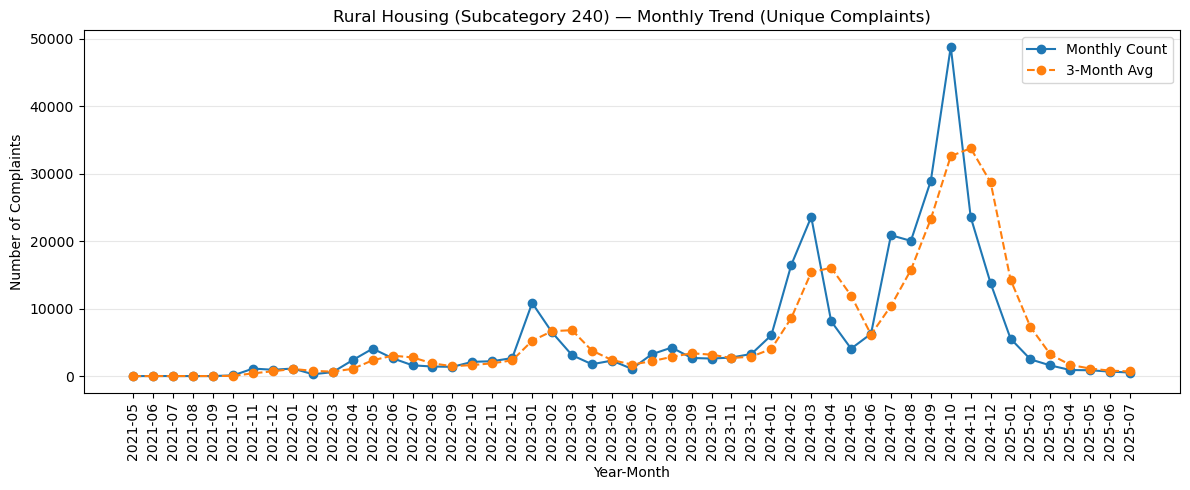

In [151]:
plot_single_trend(
    trend_240,
    "Rural Housing (Subcategory 240) — Monthly Trend (Unique Complaints)"
)



IAY/MKY/BPGY/PMAY (Subcategory 13)

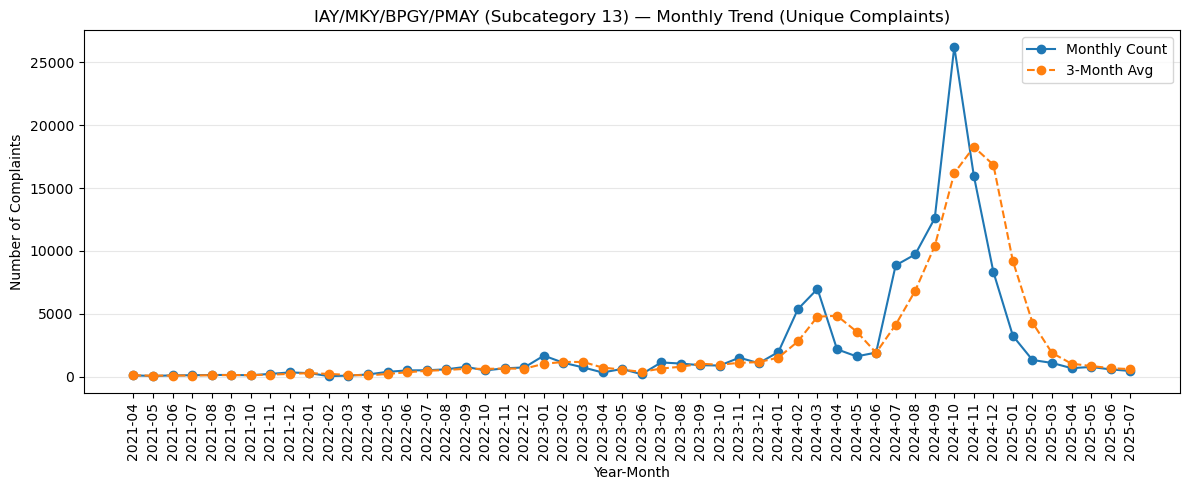

In [152]:
plot_single_trend(
    trend_13,
    "IAY/MKY/BPGY/PMAY (Subcategory 13) — Monthly Trend (Unique Complaints)"
)


Comparison between Subcategories 240 and 13

In [153]:
def compare_two_subcategories(
    df,
    subcat_a,
    subcat_b,
    name_a,
    name_b,
    exclude_months=None
):
    """
    Compare two subcategories:
    - Monthly trends
    - Peak points
    - Pearson correlation
    """

    # Build trends
    trend_a = build_monthly_trend(df, subcat_a, f'{name_a}_count')
    trend_b = build_monthly_trend(df, subcat_b, f'{name_b}_count')

    # Merge
    compare = pd.merge(trend_a, trend_b, on='year_month', how='outer')
    compare['date'] = pd.to_datetime(compare['year_month'] + '-01')
    compare = compare.sort_values('date')

    # Exclusions
    compare_clean = compare.copy()
    if exclude_months:
        compare_clean = compare_clean[
            ~compare_clean['year_month'].isin(exclude_months)
        ]

    compare_clean = compare_clean.dropna(
        subset=[f'{name_a}_count', f'{name_b}_count']
    )

    # Correlation
    corr = compare_clean[f'{name_a}_count'].corr(
        compare_clean[f'{name_b}_count'],
        method='pearson'
    )

    # Peaks
    peak_a = compare.loc[
        compare[f'{name_a}_count'].idxmax(),
        ['year_month', f'{name_a}_count']
    ]

    peak_b = compare.loc[
        compare[f'{name_b}_count'].idxmax(),
        ['year_month', f'{name_b}_count']
    ]

    # Plot
    plt.figure(figsize=(14,6))

    plt.plot(compare['year_month'], compare[f'{name_a}_count'],
             marker='o', label=name_a)

    plt.plot(compare['year_month'], compare[f'{name_b}_count'],
             marker='o', linestyle='--', label=name_b)

    plt.annotate(
        f"Peak: {int(peak_a[f'{name_a}_count'])}",
        xy=(peak_a['year_month'], peak_a[f'{name_a}_count']),
        xytext=(0,8),
        textcoords='offset points',
        fontweight='bold'
    )

    plt.annotate(
        f"Peak: {int(peak_b[f'{name_b}_count'])}",
        xy=(peak_b['year_month'], peak_b[f'{name_b}_count']),
        xytext=(0,8),
        textcoords='offset points',
        fontweight='bold'
    )

    plt.text(
        0.01, 0.97,
        f"Pearson r: {corr:.3f}",
        transform=plt.gca().transAxes,
        fontsize=11,
        fontweight='bold',
        verticalalignment='top'
    )

    plt.xticks(rotation=90)
    plt.xlabel("Year-Month")
    plt.ylabel("Number of Complaints")
    plt.title("Monthly Complaints Comparison")
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return compare, corr


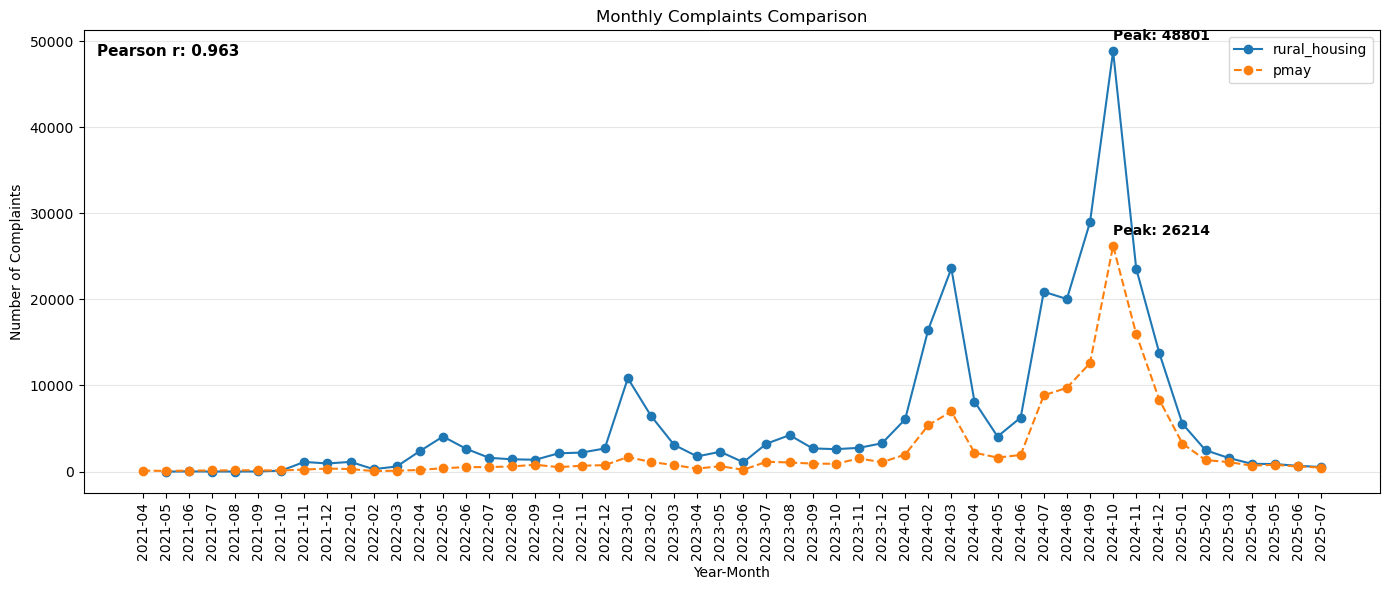

In [154]:
compare_df, corr = compare_two_subcategories(
    df_work,
    subcat_a=240,
    subcat_b=13,
    name_a='rural_housing',
    name_b='pmay',
    exclude_months=['2021-04']
)
